# **Physics-Informed Neural Networks (PINNs) for First-Order Irreversible Reactions**

This notebook demonstrates the implementation of **Physics-Informed Neural Networks (PINNs)** to solve the governing differential equations of a first-order irreversible reaction in a batch reactor. We compare two different frameworks:
1. **DeepXDE**: A library specifically designed for PINNs.
2. **PyTorch**: A manual implementation using automatic differentiation.

In this notebook, we will solve the first order reaction of an irreversible reaction of a species inside a batch reactor.

**Problem Statement**:
Consider an irreversible first order reaction of a species $A$ taking place in a batch reactor isothermally. We are known with the initial concentration of the reactant $C_0$ . We need to solve the governing differntial equation by training the neural network and see the decay of the reactant concentration with respect to time $t$.

The reaction:
$$A→R$$

The governing differential equation of this reaction is given by

$$\frac{dC}{dt} = -k C, \qquad t \in [0, 10]$$
Here, the rate constant $k$ is a function of temperature and can be expressed as an Arrhenius Rate Expression

$$k=A_0 exp(\frac{-E}{RT})$$
where,
1. $A_0$ is the pre-exponential factor : $A_0 = 1615.50 s^{-1}$
2. $E$ is the activation function: $E = 50,000 J/mol$
3. $R$ is the universal gas constant: $R = 8.314 J/mol .K$
4. $T$ is the temperature: $T = 700 K$

with the parameter

Initial Concentration $C_0 = 1 mol/L$

The analytical solution is given by $C(t) = C_0 e^{-kt}$

## 1. Problem Formulation and Parameters
In this section, we define the physical constants and the chemical kinetics governing the reaction $A \rightarrow R$.

### 1.1 DeepXDE Setup
We begin by installing and configuring the DeepXDE environment.

In [ ]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
# import libraries
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
# Defining the parameters
A0 = 1615.50    # Unit: s^-1
E = 50000   # Unit: J/mol
R = 8.314   # Unit: J/mol K
T = 700     # Unit: K
c0= 1       # Unit: mol/L

In [ ]:
# Defining the rate constant
k = A0 * np.exp(-E / (R * T))

In [ ]:
np.exp(-E / (R * T))

np.float64(0.00018570326124606157)

In [ ]:
print(k)

0.3000036185430125


In [ ]:
# Defining the computational domain
timedomain = dde.geometry.TimeDomain(0,10)

In [ ]:
# Defining the pde
def pde(t,c):
  dc_dt = dde.grad.jacobian(c, t, i=0)
  return dc_dt + k*c

In [ ]:
# Defining the exact solution
def exact(t):
  return c0*np.exp(-k*t)

In [ ]:
# Defining the initial conditions
def on_initial(t, on_boundary):
  return on_boundary and dde.utils.isclose(t[0], 0)

ic = dde.icbc.IC(timedomain, lambda t:c0, on_initial)

In [ ]:
# Defining the problem
data = dde.data.PDE(timedomain, pde, ic, num_domain= 50, num_boundary=1, solution=exact)

In [ ]:
# Defining the neural network
layer_size = [1] + [15]*3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

In [ ]:
# Initializing the model and train it
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000)
# dde.saveplot(losshistory, train_state, isplot=True, issave=True)

Compiling model...
'compile' took 0.006331 s



Cause: could not parse the source code of <function <lambda> at 0x796833d0de40>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Training model...

Cause: could not parse the source code of <function <lambda> at 0x796833d0de40>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric   
0         [2.79e-01, 1.00e+00]    [2.79e-01, 1.00e+00]    [3.31e+00]    
1000      [8.64e-05, 2.13e-08]    [8.64e-05, 2.13e-08]    [7.00e-03]    
2000      [3.39e-05, 3.40e-09]    [3.39e-05, 3.40e-09]    [3.91e-03]    
3000      [1.70e-05, 1.01e-09]    [1.70e-05, 1.01e-09]    [2.73e-03]    
4000      [8.39e-06, 3.15e-10]    [8.39e-06, 3.15e-10]    [1.78e-03]    
5000      [4.54e-06, 9.91e-11]    [4.54e-06, 9.91e-11]    [

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


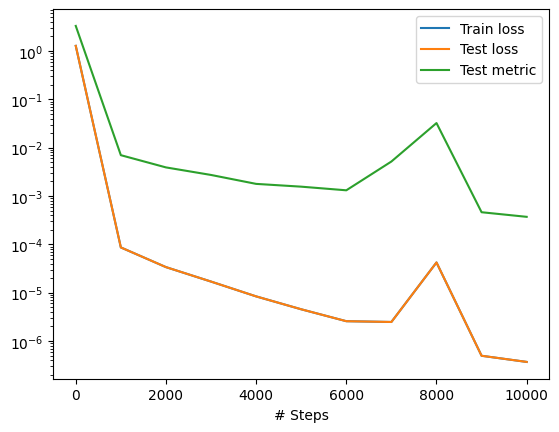

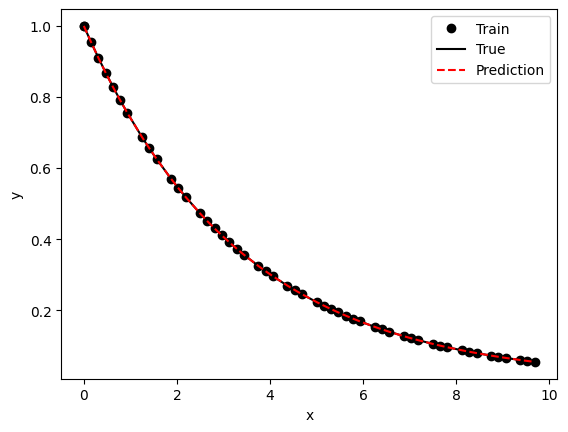

In [ ]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

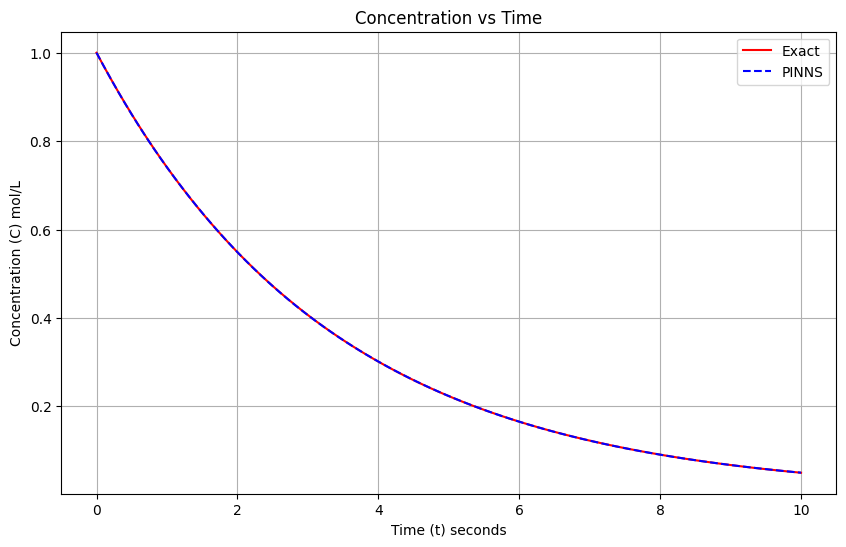

In [ ]:
# Plotting the results

# Crearting the data for t
t = np.linspace(0, 10, 100).reshape(-1, 1)

# Predict the concentration
c_pred = model.predict(t)

# Calculate the exact concentration
c_exat = exact(t)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, c_exat,'r-' ,label="Exact")
plt.plot(t, c_pred,'b--', label="PINNS")
plt.xlabel("Time (t) seconds")
plt.ylabel("Concentration (C) mol/L")
plt.title("Concentration vs Time")
plt.legend()
plt.grid(True)
plt.show()

## 2. PyTorch Implementation
In this section, we build a custom PINN from scratch using PyTorch to solve the same kinetic model without high-level PINN libraries.

In [ ]:
# import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Defining the parameters
A0 = 1615.50    # Unit: s^-1
E = 50000   # Unit: J/mol
R = 8.314   # Unit: J/mol K
T = 700     # Unit: K
c0= 1       # Unit: mol/L

In [ ]:
# Defining the rate constant
k = A0 * np.exp(-E / (R * T))

In [ ]:
# Defining the neural network
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(1, 15)
    self.fc2 = nn.Linear(15, 15)
    self.fc3 = nn.Linear(15, 15)
    self.fc4 = nn.Linear(15, 1)

  def forward(self, t):
    a1 = F.tanh(self.fc1(t))
    a2 = F.tanh(self.fc2(a1))
    a3 = F.tanh(self.fc3(a2))
    output = self.fc4(a3)
    return output
net = Net()
print(net)

Net(
  (fc1): Linear(in_features=1, out_features=15, bias=True)
  (fc2): Linear(in_features=15, out_features=15, bias=True)
  (fc3): Linear(in_features=15, out_features=15, bias=True)
  (fc4): Linear(in_features=15, out_features=1, bias=True)
)


In [ ]:
# Defining the pde
def pde(net, t):
  C = net(t)

  # Defining the derivatives
  dC_dt = torch.autograd.grad(C, t, torch.ones_like(C), create_graph=True)[0]

  # Defining the equation
  pde_res = dC_dt + k*C
  return pde_res

In [ ]:
# Defining the loss function
def compute_loss(net, t, t_ic, C_ic):
  # Defining the type of loss function
  mse_loss = nn.MSELoss()

  # PDE Loss
  pde_res = pde(net, t)
  pde_loss = mse_loss(pde_res, torch.zeros_like(pde_res))

  # IC Loss
  ic_res = net(t_ic) - C_ic
  ic_loss = mse_loss(ic_res, torch.zeros_like(ic_res))

  total_loss = pde_loss + ic_loss
  return total_loss, pde_loss, ic_loss

In [ ]:
# Defining the collocation points
t = torch.linspace(0, 10, 100).reshape(-1, 1).requires_grad_(True)
t_ic = torch.tensor([[0.0]]).requires_grad_(True)
C_ic = torch.tensor([float(c0)])


In [ ]:
# Training the neural network
epochs = 10000
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Storing all the losses
total_loss_list = []
pde_loss_list = []
ic_loss_list = []

for epoch in range(epochs+1):
  optimizer.zero_grad()
  loss_val, p_loss, i_loss = compute_loss(net, t, t_ic, C_ic)
  loss_val.backward()
  optimizer.step()

  # Appending scalar values to lists
  total_loss_list.append(loss_val.item())
  pde_loss_list.append(p_loss.item())
  ic_loss_list.append(i_loss.item())

  if epoch % 1000 == 0:
    print(f"Epoch: {epoch}, Total Loss: {loss_val.item(): .4e}, PDE Loss: {p_loss.item(): .4e}, IC Loss: {i_loss.item(): .4e}")

Epoch: 0, Total Loss:  1.6095e-07, PDE Loss:  1.2045e-08, IC Loss:  1.4890e-07
Epoch: 1000, Total Loss:  8.5718e-09, PDE Loss:  8.5716e-09, IC Loss:  2.2737e-13
Epoch: 2000, Total Loss:  6.9701e-09, PDE Loss:  6.7111e-09, IC Loss:  2.5899e-10
Epoch: 3000, Total Loss:  6.5805e-09, PDE Loss:  6.5791e-09, IC Loss:  1.4211e-12
Epoch: 4000, Total Loss:  2.8757e-06, PDE Loss:  3.8768e-08, IC Loss:  2.8369e-06
Epoch: 5000, Total Loss:  5.9743e-09, PDE Loss:  5.6755e-09, IC Loss:  2.9878e-10
Epoch: 6000, Total Loss:  5.2734e-09, PDE Loss:  5.2704e-09, IC Loss:  2.9878e-12
Epoch: 7000, Total Loss:  1.3784e-08, PDE Loss:  1.3566e-08, IC Loss:  2.1851e-10
Epoch: 8000, Total Loss:  5.9650e-09, PDE Loss:  4.8667e-09, IC Loss:  1.0983e-09
Epoch: 9000, Total Loss:  6.8197e-09, PDE Loss:  4.6305e-09, IC Loss:  2.1893e-09
Epoch: 10000, Total Loss:  5.9441e-06, PDE Loss:  8.3899e-08, IC Loss:  5.8602e-06


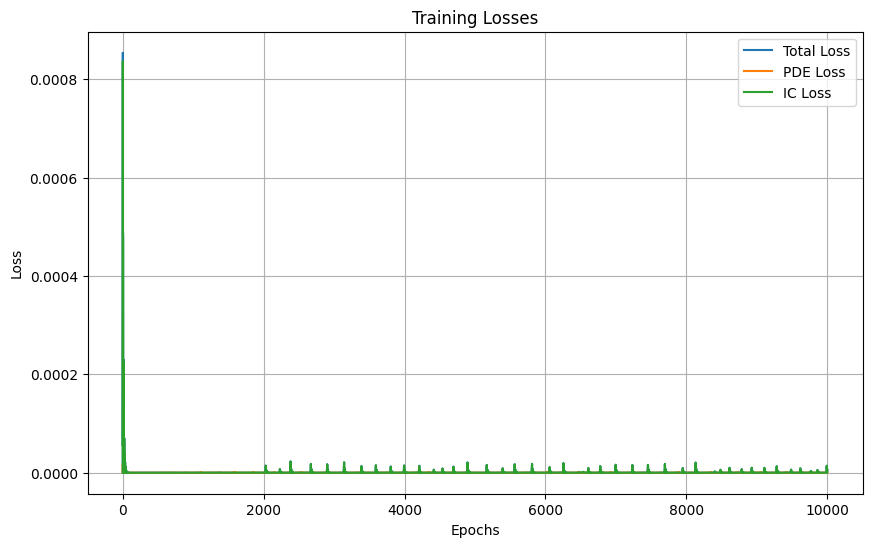

In [ ]:
# Plotting he losses
plt.figure(figsize=(10, 6))
plt.plot(total_loss_list, label="Total Loss")
plt.plot(pde_loss_list, label="PDE Loss")
plt.plot(ic_loss_list, label="IC Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True)
plt.show()

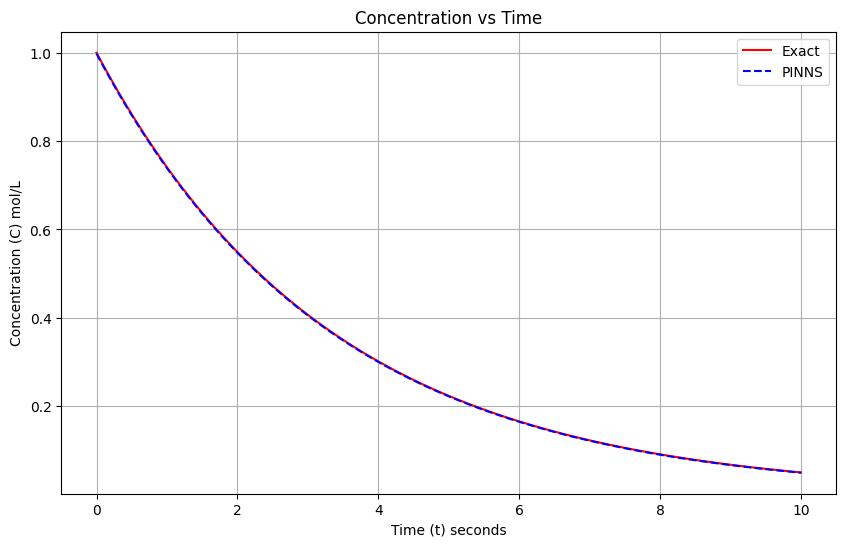

In [ ]:
# Plotting the results of PINN with the analytical solution
with torch.no_grad():
  t_plot = torch.linspace(0, 10, 100).reshape(-1, 1)
  c_pred_pytorch = net(t_plot).numpy()
t_eval = np.linspace(0, 10, 100).reshape(-1, 1)
c_exat = c0*np.exp(-k*t_eval)

plt.figure(figsize=(10, 6))
plt.plot(t_eval, c_exat, 'r-', label="Exact")
plt.plot(t_plot.numpy(), c_pred_pytorch, 'b--', label="PINNS")
plt.xlabel("Time (t) seconds")
plt.ylabel("Concentration (C) mol/L")
plt.title("Concentration vs Time")
plt.legend()
plt.grid(True)
plt.show()


## 3. Conclusion
Both DeepXDE and the manual PyTorch implementation successfully capture the exponential decay of the reactant concentration. PINNs provide a robust way to integrate physical laws (ODEs) directly into the neural network's loss function.